# Manuscrito: relações entre parasita, dispersor e hospedeiros
por **Eduardo Oliveira**
# Árvores de classificação: 
i) Descobrir as variáveis mais importantes para a ocorrência do parasita

ii) Fazer previsões para outras área.

In [1]:
import os
print(os.getcwd())#mostrar o diretorio atual

C:\Users\Eduardo Oliveira.PIBILab-01\Documents\Eduardo Oliveira\Python\Parasita_Inter_ML\Rodada2


In [2]:
##Importando as bibliotecas

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import random


In [6]:
dados=pd.read_excel('mpa_filtrado.xlsx') 
dados.head()

,Probu,Cadam,Dhirs,Ecris,Malbi,Mferr,Qcord,Qdich,Qgran,Qmult,...,Vrufa,Vthyr,Vtuca,bio2,bio3,bio10,bio13,bio15,bio18,bio19
0,0,0,0,1,1,0,0,0,0,0,...,0,0,0,8.818344,79.373535,28.014324,366.479218,82.965012,216.653305,963.933716
1,0,0,0,1,1,0,0,0,0,0,...,0,0,0,9.231052,72.239632,25.264219,159.472229,62.844238,234.270828,370.854156
2,0,0,0,0,0,0,0,0,1,0,...,0,0,0,11.730132,62.359577,25.247437,192.055557,40.613277,508.298615,220.583328
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,12.497600,71.994499,16.047474,30.472815,103.407951,68.256363,2.185698
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,9.832417,87.159088,26.039833,360.000000,18.673700,627.000000,904.000000


In [77]:
#Removendo uma coluna
#dados = dados.drop(columns=['id','Longitude(x)','Latitude(y)','bio20'], axis=1)
#dados

In [7]:
#Checando presenças e ausências do parasita
pd.crosstab(dados['Probu'],columns='Total')

col_0,Total
Probu,
0,167
1,167


In [8]:
# Separa as variáveis preditoras (X) e a resposta (y)
X = dados.drop('Probu', axis=1) #1 para colunas
y = dados['Probu']

In [9]:
# dados de treinamento e teste: 80% para treinamento e 20% para teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [10]:
# Cria uma árvore de decisão
# algoritmo DecisionTreeClassifier (árvore de decisão)
arvore = DecisionTreeClassifier(max_depth=3)

# Treina a árvore de decisão usando os dados de treinamento
arvore.fit(X_train, y_train)

# Usa a árvore de decisão para prever os rótulos da base de teste
y_pred = arvore.predict(X_test)

In [12]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# Acurácia
acc = accuracy_score(y_test, y_pred)

print('Métricas de desempenho para aprendizado supervisionado em classificação binária')
print("\nAcurácia:", np.round(acc,3))

# Para a classe 1
precision = precision_score(y_test, y_pred, pos_label=1,zero_division=0)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)
print("\nPrecisão (para a classe 1):", np.round(precision,3))
print("Recall (para a classe 1):", np.round(recall,3))
print("F1-score (para a classe 1):", np.round(f1,3))

# Para a classe 0
precision = precision_score(y_test, y_pred, pos_label=0)
recall = recall_score(y_test, y_pred, pos_label=0)
f1 = f1_score(y_test, y_pred, pos_label=0)
print("\nPrecisão (para a classe 0):", np.round(precision,3))
print("Recall (para a classe 0):", np.round(recall,3))
print("F1-score (para a classe 0):", np.round(f1,3))

Métricas de desempenho para aprendizado supervisionado em classificação binária

Acurácia: 0.806

Precisão (para a classe 1): 0.833
Recall (para a classe 1): 0.758
F1-score (para a classe 1): 0.794

Precisão (para a classe 0): 0.784
Recall (para a classe 0): 0.853
F1-score (para a classe 0): 0.817


# Métricas de avaliação (baseada na matriz de confusão)

Precisão = mede a qualidade das previsões positivas (verdadeiros positivos); modelo comete poucos erros.

Recall = taxa de verdadeiros positivos

F1-score = média harmônica entre precisão e recall

Obs. na classe 1, o modelo acerta em 88% das vezes e na classe 0 em 88%.

In [13]:
from sklearn.model_selection import GridSearchCV

# Uso da validação cruzada para encontrar a melhor árvore
param_grid = {
    'max_depth': range(1, 11),
    'min_samples_split': range(2, 11),
    'min_samples_leaf': range(1, 6)
}

# Realiza a busca em grid com cross-validation para encontrar a melhor árvore
grid = GridSearchCV(arvore, param_grid, cv=2)
grid.fit(X_train, y_train)

# Usa a árvore de decisão para prever os rótulos da base de teste
y_pred = grid.predict(X_test)

# Melhor árvore escolhida
print(f"Melhores parâmetros: {grid.best_params_}")
print(f"Acurácia da melhor árvore: {grid.best_score_}")

Melhores parâmetros: {'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2}
Acurácia da melhor árvore: 0.8277690494893951


In [14]:
# Acurácia
acc = accuracy_score(y_test, y_pred)

print('Métricas de desempenho para aprendizado supervisionado em classificação binária')
print("\nAcurácia:", np.round(acc,3))

# Para a classe 1
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)
print("\nPrecisão (para a classe 1):", np.round(precision,3))
print("Recall (para a classe 1):", np.round(recall,3))
print("F1-score (para a classe 1):", np.round(f1,3))

# Para a classe 0
precision = precision_score(y_test, y_pred, pos_label=0)
recall = recall_score(y_test, y_pred, pos_label=0)
f1 = f1_score(y_test, y_pred, pos_label=0)
print("\nPrecisão (para a classe 0):", np.round(precision,3))
print("Recall (para a classe 0):", np.round(recall,3))
print("F1-score (para a classe 0):", np.round(f1,3))

Métricas de desempenho para aprendizado supervisionado em classificação binária

Acurácia: 0.866

Precisão (para a classe 1): 0.833
Recall (para a classe 1): 0.909
F1-score (para a classe 1): 0.87

Precisão (para a classe 0): 0.903
Recall (para a classe 0): 0.824
F1-score (para a classe 0): 0.862


Ficou um pouco pior do que o resultado anterior

In [16]:
#Acessando a importância das variáveis

import pandas as pd

importances = arvore.feature_importances_

# Combinar com os nomes das variáveis
feature_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Ordenar por importância 
importance_df = importance_df.sort_values(by='Importance', ascending=False)
print(importance_df)


   Feature  Importance
9    Qparv    0.640258
3    Malbi    0.154148
22   bio10    0.078834
4    Mferr    0.049092
21    bio3    0.040634
23   bio13    0.019940
25   bio18    0.017095
0    Cadam    0.000000
15   Vcinn    0.000000
24   bio15    0.000000
20    bio2    0.000000
19   Vtuca    0.000000
18   Vthyr    0.000000
17   Vrufa    0.000000
16   Velli    0.000000
13   Tsaya    0.000000
14   Tlani    0.000000
1    Dhirs    0.000000
12   Tviri    0.000000
11   Srufi    0.000000
10   Sconv    0.000000
8    Qmult    0.000000
7    Qgran    0.000000
6    Qdich    0.000000
5    Qcord    0.000000
2    Ecris    0.000000
26   bio19    0.000000


In [17]:
#!pip install openpyxl
import openpyxl as op

# Salvar como Excel
importance_df.to_excel('feature_importances.xlsx', index=False, engine='openpyxl')


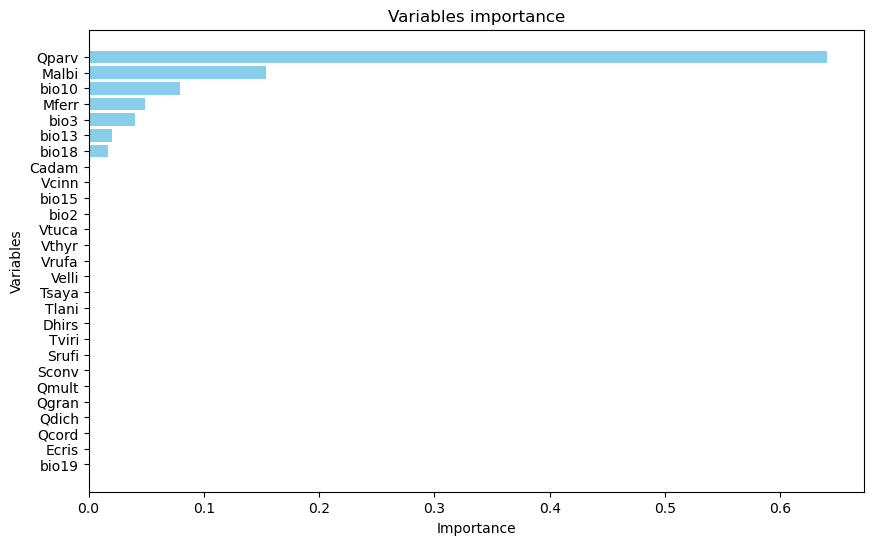

In [18]:
import matplotlib.pyplot as plt

# Plotar as importâncias
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.gca().invert_yaxis()  # Inverter a ordem para que a variável mais importante fique no topo
plt.xlabel('Importance')
plt.ylabel('Variables')
plt.title('Variables importance')

# Salvar a figura
plt.savefig('importance_var.jpg', dpi=300, bbox_inches='tight')#png
plt.show()


# Algoritmo Bagging

É uma técnica de criar conjuntos de dados de treinamento por meio de amostragem aleatória.

In [19]:
from sklearn.ensemble import BaggingClassifier

# Inicializa o classificador por árvore de decisão
tree = DecisionTreeClassifier()

# Inicializa o classificador por Bagging 
# Agregador de bootstrap
bagging = BaggingClassifier(estimator=tree, n_estimators=20, random_state=42)

# Ajusta o classificador por Bagging aos dados de treinamento
bagging.fit(X_train, y_train)

# Prediz a resposta para a base de teste
y_pred = bagging.predict(X_test)


In [20]:
# Avalia a performance do classificador por Bagging nos dados de teste 
score = bagging.score(X_test, y_test)

print('Métricas de desempenho para aprendizado supervisionado em classificação binária')
print("\nAcurácia:", np.round(score,3))

# Para a classe 1
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)
print("\nPrecisão (para a classe 1):", np.round(precision,3))
print("Recall (para a classe 1):", np.round(recall,3))
print("F1-score (para a classe 1):", np.round(f1,3))

# Para a classe 0
precision = precision_score(y_test, y_pred, pos_label=0)
recall = recall_score(y_test, y_pred, pos_label=0)
f1 = f1_score(y_test, y_pred, pos_label=0)
print("\nPrecisão (para a classe 0):", np.round(precision,3))
print("Recall (para a classe 0):", np.round(recall,3))
print("F1-score (para a classe 0):", np.round(f1,3))

Métricas de desempenho para aprendizado supervisionado em classificação binária

Acurácia: 0.881

Precisão (para a classe 1): 0.903
Recall (para a classe 1): 0.848
F1-score (para a classe 1): 0.875

Precisão (para a classe 0): 0.861
Recall (para a classe 0): 0.912
F1-score (para a classe 0): 0.886


In [21]:
#Acessando a importância das variáveis

import numpy as np
import pandas as pd

# Obter as importâncias das árvores individuais
feature_importances = [
    tree.feature_importances_ for tree in bagging.estimators_
]

# Calcular a média das importâncias
mean_importances = np.mean(feature_importances, axis=0)

# Combinar com os nomes das variáveis (supondo que X_train seja um DataFrame)
feature_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': mean_importances})

# Ordenar por importância (decrescente)
importance_df = importance_df.sort_values(by='Importance', ascending=False)
print(importance_df)


   Feature  Importance
9    Qparv    0.356544
3    Malbi    0.080426
22   bio10    0.060812
4    Mferr    0.057592
20    bio2    0.056317
21    bio3    0.054892
24   bio15    0.053972
7    Qgran    0.043110
25   bio18    0.031677
23   bio13    0.028817
26   bio19    0.027234
2    Ecris    0.026088
19   Vtuca    0.016721
1    Dhirs    0.016037
8    Qmult    0.014855
17   Vrufa    0.014617
18   Vthyr    0.012802
5    Qcord    0.010793
6    Qdich    0.010187
10   Sconv    0.010080
16   Velli    0.007757
15   Vcinn    0.004009
13   Tsaya    0.003762
12   Tviri    0.000624
14   Tlani    0.000273
11   Srufi    0.000000
0    Cadam    0.000000


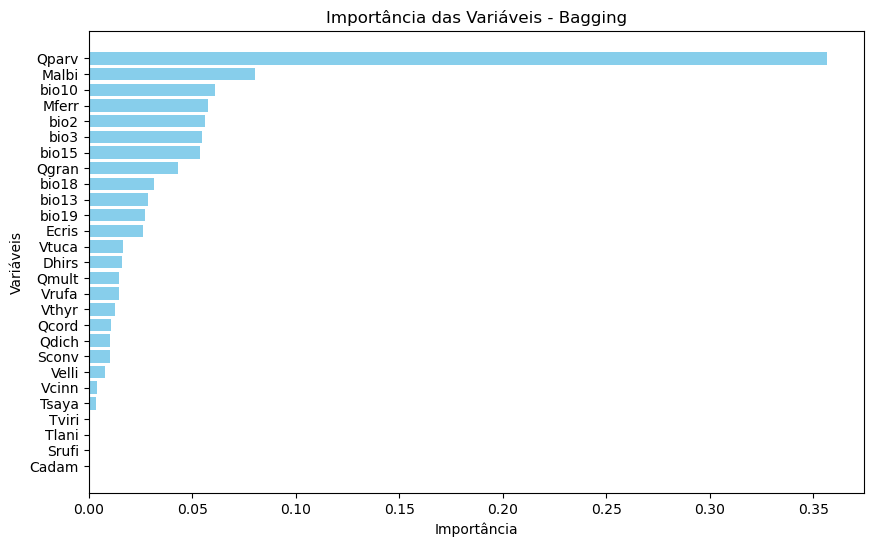

In [22]:
#Visualizando os resultados

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.gca().invert_yaxis()
plt.xlabel('Importância')
plt.ylabel('Variáveis')
plt.title('Importância das Variáveis - Bagging')

# Salvar a figura
plt.savefig('importance_var_bag.jpg', dpi=300, bbox_inches='tight')#png
plt.show()


# Algoritmo Boosting

Combina um conjunto de aprendizes fracos em um aprendiz forte para minimizar erros de treinamento.

In [23]:
from sklearn.ensemble import AdaBoostClassifier

# Inicializa o classificador por árvore de decisão
tree = DecisionTreeClassifier(max_depth=3)

# Inicializa o classificador AdaBoost
adaboost = AdaBoostClassifier(estimator=tree, n_estimators=50, learning_rate=1, random_state=42)

# Ajusta o classificador AdaBoost aos dados de treinamento
adaboost.fit(X_train, y_train)

# Prediz para a base de teste
y_pred = adaboost.predict(X_test)

# Avalia a performance do classificador AdaBoost nos dados de teste 
score = adaboost.score(X_test, y_test)

print('Métricas de desempenho para aprendizado supervisionado em classificação binária')
print("\nAcurácia:", np.round(score,3))

# Para a classe 1
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)
print("\nPrecisão (para a classe 1):", np.round(precision,3))
print("Recall (para a classe 1):", np.round(recall,3))
print("F1-score (para a classe 1):", np.round(f1,3))

# Para a classe 0
precision = precision_score(y_test, y_pred, pos_label=0)
recall = recall_score(y_test, y_pred, pos_label=0)
f1 = f1_score(y_test, y_pred, pos_label=0)
print("\nPrecisão (para a classe 0):", np.round(precision,3))
print("Recall (para a classe 0):", np.round(recall,3))
print("F1-score (para a classe 0):", np.round(f1,3))

Métricas de desempenho para aprendizado supervisionado em classificação binária

Acurácia: 0.866

Precisão (para a classe 1): 0.853
Recall (para a classe 1): 0.879
F1-score (para a classe 1): 0.866

Precisão (para a classe 0): 0.879
Recall (para a classe 0): 0.853
F1-score (para a classe 0): 0.866


C:\Users\Eduardo Oliveira.PIBILab-01\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


# Random Forest

In [25]:
from sklearn.ensemble import RandomForestClassifier

# Ajusta um classificador por florestas aleatórias
clf = RandomForestClassifier(n_estimators=200, random_state=10)
clf.fit(X_train, y_train)

# Obtém predições para a base de teste
y_pred = clf.predict(X_test)

# Avalia a performance do classificador por florestas aleatórias nos dados de teste 
acc = accuracy_score(y_test, y_pred)

print('Métricas de desempenho para aprendizado supervisionado em classificação binária')
print("\nAcurácia:", np.round(acc,3))

# Para a classe 1
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)
print("\nPrecisão (para a classe 1):", np.round(precision,3))
print("Recall (para a classe 1):", np.round(recall,3))
print("F1-score (para a classe 1):", np.round(f1,3))

# Para a classe 0
precision = precision_score(y_test, y_pred, pos_label=0)
recall = recall_score(y_test, y_pred, pos_label=0)
f1 = f1_score(y_test, y_pred, pos_label=0)
print("\nPrecisão (para a classe 0):", np.round(precision,3))
print("Recall (para a classe 0):", np.round(recall,3))
print("F1-score (para a classe 0):", np.round(f1,3))

Métricas de desempenho para aprendizado supervisionado em classificação binária

Acurácia: 0.91

Precisão (para a classe 1): 0.909
Recall (para a classe 1): 0.909
F1-score (para a classe 1): 0.909

Precisão (para a classe 0): 0.912
Recall (para a classe 0): 0.912
F1-score (para a classe 0): 0.912


In [26]:
# Importância das variáveis

import pandas as pd

# Obter a importância das variáveis
importances = clf.feature_importances_

# Criar um DataFrame para exibir os resultados
feature_names = X_train.columns  # Supondo que X_train seja um DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Ordenar as variáveis por importância (decrescente)
importance_df = importance_df.sort_values(by='Importance', ascending=False)
print(importance_df)


   Feature  Importance
9    Qparv    0.144035
24   bio15    0.109343
7    Qgran    0.067471
21    bio3    0.063797
3    Malbi    0.061676
23   bio13    0.055698
22   bio10    0.054480
25   bio18    0.052596
10   Sconv    0.051260
20    bio2    0.049916
4    Mferr    0.045325
17   Vrufa    0.043706
26   bio19    0.043071
8    Qmult    0.035793
19   Vtuca    0.022625
6    Qdich    0.020937
2    Ecris    0.019486
18   Vthyr    0.017148
16   Velli    0.013321
1    Dhirs    0.006929
5    Qcord    0.006744
15   Vcinn    0.005641
13   Tsaya    0.004182
0    Cadam    0.002258
14   Tlani    0.001037
12   Tviri    0.000873
11   Srufi    0.000652


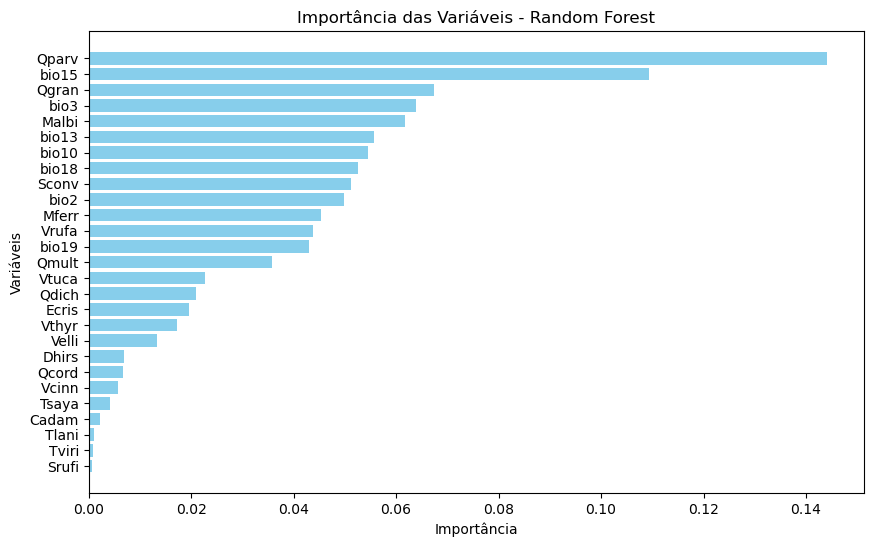

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.gca().invert_yaxis()
plt.xlabel('Importância')
plt.ylabel('Variáveis')
plt.title('Importância das Variáveis - Random Forest')

# Salvar a figura
plt.savefig('importance_var_RF.jpg', dpi=300, bbox_inches='tight')#png
plt.show()

# Calcular os valores de Shapley (Shapley Values)

DataFrame com as variáveis preditoras (hospedeiros, dispersores e variáveis climáticas) e a variável resposta (presença/ausência da erva-de-passarinho).



# Random Forest

In [34]:
pip install shap scikit-learn pandas numpy matplotlib


   ---------------------------------------- 0.0/545.3 kB ? eta -:--:--
   ---------------------------------------- 545.3/545.3 kB 6.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [48]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [49]:
# Carregar dados 
dados=pd.read_excel('mpa_filtrado.xlsx') 
dados.head()


,Probu,Cadam,Dhirs,Ecris,Malbi,Mferr,Qcord,Qdich,Qgran,Qmult,...,Vrufa,Vthyr,Vtuca,bio2,bio3,bio10,bio13,bio15,bio18,bio19
0,0,0,0,1,1,0,0,0,0,0,...,0,0,0,8.818344,79.373535,28.014324,366.479218,82.965012,216.653305,963.933716
1,0,0,0,1,1,0,0,0,0,0,...,0,0,0,9.231052,72.239632,25.264219,159.472229,62.844238,234.270828,370.854156
2,0,0,0,0,0,0,0,0,1,0,...,0,0,0,11.730132,62.359577,25.247437,192.055557,40.613277,508.298615,220.583328
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,12.497600,71.994499,16.047474,30.472815,103.407951,68.256363,2.185698
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,9.832417,87.159088,26.039833,360.000000,18.673700,627.000000,904.000000


In [50]:
dados.columns

Index(['Probu', 'Cadam', 'Dhirs', 'Ecris', 'Malbi', 'Mferr', 'Qcord', 'Qdich',
       'Qgran', 'Qmult', 'Qparv', 'Sconv', 'Srufi', 'Tviri', 'Tsaya', 'Tlani',
       'Vcinn', 'Velli', 'Vrufa', 'Vthyr', 'Vtuca', 'bio2', 'bio3', 'bio10',
       'bio13', 'bio15', 'bio18', 'bio19'],
      dtype='object')

In [51]:
# Definir variáveis preditoras (X) e variável resposta (y)
var_preds = ['Cadam', 'Dcaya', 'Dhirs', 'Ecris', 'Malbi', 'Mferr', 'Qcord',
       'Qdich', 'Qgran', 'Qmult', 'Qparv', 'Sconv', 'Srufi', 'Tviri', 'Tsaya',
       'Tlani', 'Vcinn', 'Velli', 'Vrufa', 'Vthyr', 'Vtuca', 'bio2', 'bio3',
       'bio10', 'bio13', 'bio15', 'bio18', 'bio19']  
X = dados[var_preds]
y = dados["Probu"]  # Nome da variável resposta


KeyError: "['Dcaya'] not in index"

In [52]:
# Dividir os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Treinar modelo (pode substituir por outro modelo)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [53]:
# Avaliar modelo
y_pred = model.predict(X_test)
print("Acurácia:", accuracy_score(y_test, y_pred))


Acurácia: 0.8955223880597015


In [54]:
# Criar explicador SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

In [55]:
print(type(shap_values))  # Deve ser uma lista
print(len(shap_values))   # Deve ser 2 (uma para cada classe)
print(np.array(shap_values).shape)  # Deve mostrar (2, n_samples, n_features)


<class 'numpy.ndarray'>
67
(67, 27, 2)


In [56]:
import matplotlib.pyplot as plt

plt.figure()  # Cria uma nova figura
shap.summary_plot(shap_values_selected, X_test, show=False)  # Não mostrar na tela
plt.savefig("shap_summary.png", dpi=600, bbox_inches="tight")  # Salvar como PNG
plt.close()  # Fecha a figura para não exibir


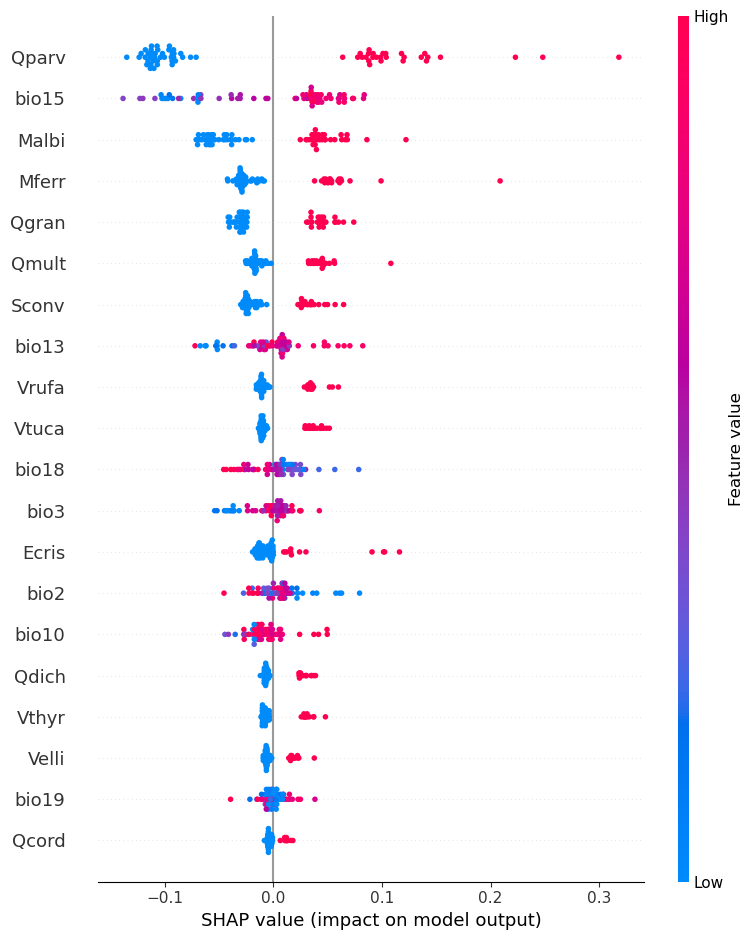

In [57]:
shap_values_selected = shap_values[:, :, 1]  # Pega apenas os valores da classe "1"
shap.summary_plot(shap_values_selected, X_test)


In [58]:
print(X_test.columns)

Index(['Cadam', 'Dhirs', 'Ecris', 'Malbi', 'Mferr', 'Qcord', 'Qdich', 'Qgran',
       'Qmult', 'Qparv', 'Sconv', 'Srufi', 'Tviri', 'Tsaya', 'Tlani', 'Vcinn',
       'Velli', 'Vrufa', 'Vthyr', 'Vtuca', 'bio2', 'bio3', 'bio10', 'bio13',
       'bio15', 'bio18', 'bio19'],
      dtype='object')


In [59]:
plt.figure()  # Cria uma nova figura
shap.dependence_plot("Qparv", shap_values_selected, X_test, show=False)  # Não mostrar na tela
plt.savefig("shap_dependence_bio1.png", dpi=300, bbox_inches="tight")  # Salvar como PNG
plt.close()


<Figure size 640x480 with 0 Axes>

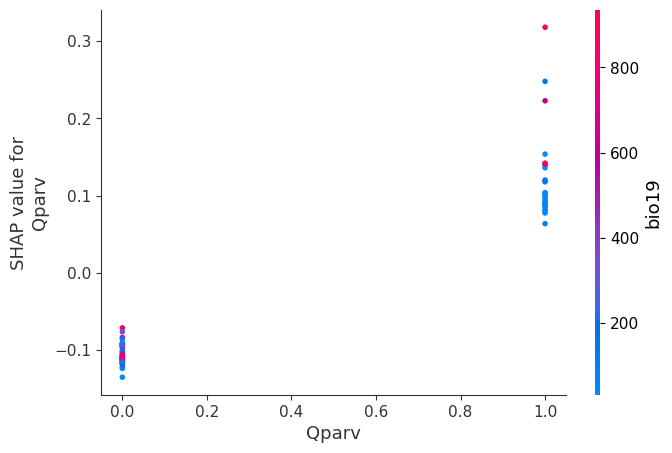

In [60]:
# Dependência individual das variáveis
shap.dependence_plot("Qparv", shap_values_selected, X_test)


# Média absoluta dos Shap Values

In [61]:
import pandas as pd
import numpy as np

# Calcular a média absoluta dos SHAP values para cada variável
mean_shap_values = np.abs(shap_values_selected).mean(axis=0)

# Criar um DataFrame com os resultados
shap_df = pd.DataFrame({"Variável": X_test.columns, "Mean_SHAP": mean_shap_values})

# Ordenar do maior para o menor impacto
shap_df = shap_df.sort_values(by="Mean_SHAP", ascending=False)

# Mostrar o DataFrame
print(shap_df)

# Salvar como CSV
shap_df.to_csv("shap_mean_values.csv", index=False)


   Variável  Mean_SHAP
9     Qparv   0.111097
24    bio15   0.056863
3     Malbi   0.050073
4     Mferr   0.037681
7     Qgran   0.036793
8     Qmult   0.026018
10    Sconv   0.025902
23    bio13   0.022594
17    Vrufa   0.017873
19    Vtuca   0.017670
25    bio18   0.017348
21     bio3   0.015194
2     Ecris   0.015090
20     bio2   0.014952
22    bio10   0.014296
6     Qdich   0.012665
18    Vthyr   0.012397
16    Velli   0.009415
26    bio19   0.007407
5     Qcord   0.005078
15    Vcinn   0.004637
1     Dhirs   0.004156
13    Tsaya   0.001637
0     Cadam   0.001361
14    Tlani   0.000744
11    Srufi   0.000341
12    Tviri   0.000248


C:\Users\Eduardo Oliveira.PIBILab-01\AppData\Local\Temp\ipykernel_20736\2086086430.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=shap_df["Variável"], x=shap_df["Mean_SHAP"], palette="viridis")


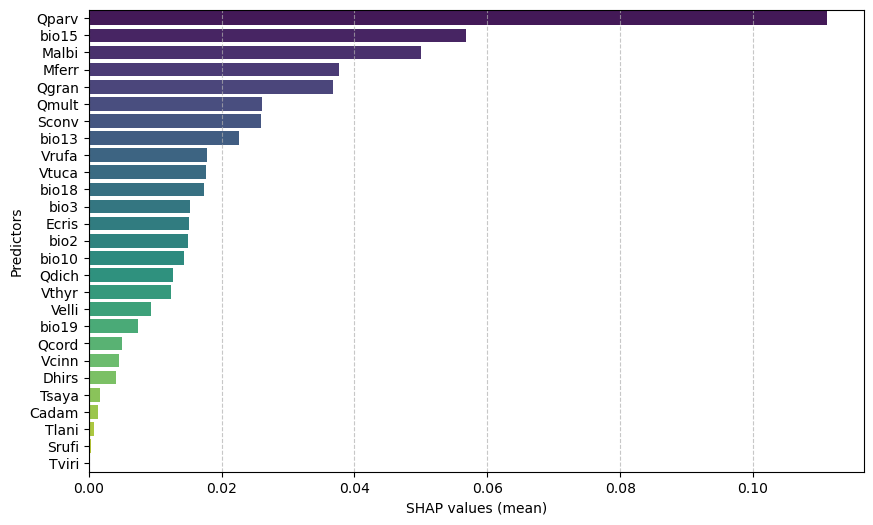

In [62]:
#Fazendo o gráfico

import seaborn as sns
import matplotlib.pyplot as plt

# Criar o gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(y=shap_df["Variável"], x=shap_df["Mean_SHAP"], palette="viridis")

# Adicionar rótulos
plt.xlabel("SHAP values (mean)")
plt.ylabel("Predictors")
plt.grid(axis="x", linestyle="--", alpha=0.7)

# Salvar o gráfico
plt.savefig("shap_importance_barplot.png", dpi=600, bbox_inches="tight")

# Mostrar o gráfico
plt.show()


# Treinar e avaliar modelos XGBoost e CatBoost com métricas de classificação binária

In [68]:
pip install xgboost catboost scikit-learn

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 479.2 kB/s eta 0:03:32
   ---------------------------------------- 0.5/101.7 MB 479.2 kB/s eta 0:03:32
   ---------------------------------------- 0.5/101.7 MB 479.2 kB/s eta 0:03:32
   ---------------------------------------- 0.8/101.7 MB 435.8 kB/s eta 0:03:52
   ---------------------------------------- 0.8/101.7 MB 435.8 kB/s eta 0:03:52
   ---------------------------------------- 1.0/101.7 MB 461.8 kB/s eta 0:03:38
   ---------------------------------------- 1.0/101.7 MB 461.8 kB/s eta 0:03:38
    --------------------------------------- 1.3/101.7 MB 486.4 kB/s eta 0:03:27
    -

In [63]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [64]:
# Treinar e avaliar um modelo de classificação
def train_and_evaluate_model(model, model_name, X_train, X_test, y_train, y_test):
    print(f"\nTreinando e avaliando {model_name}...\n")
    
    # Treina o modelo
    model.fit(X_train, y_train)
    
    # Faz previsões
    y_pred = model.predict(X_test)
    
    # Calcula métricas
    acc = accuracy_score(y_test, y_pred)
    precision_1 = precision_score(y_test, y_pred, pos_label=1)
    recall_1 = recall_score(y_test, y_pred, pos_label=1)
    f1_1 = f1_score(y_test, y_pred, pos_label=1)
    
    precision_0 = precision_score(y_test, y_pred, pos_label=0)
    recall_0 = recall_score(y_test, y_pred, pos_label=0)
    f1_0 = f1_score(y_test, y_pred, pos_label=0)
    
    # Exibe os resultados
    print("Métricas de desempenho:")
    print("\nAcurácia:", np.round(acc, 3))
    print("\nPara a classe 1:")
    print("Precisão:", np.round(precision_1, 3))
    print("Recall:", np.round(recall_1, 3))
    print("F1-score:", np.round(f1_1, 3))
    
    print("\nPara a classe 0:")
    print("Precisão:", np.round(precision_0, 3))
    print("Recall:", np.round(recall_0, 3))
    print("F1-score:", np.round(f1_0, 3))


In [65]:
# Definir hiperparâmetros e inicializar modelos
xgb_model = XGBClassifier(n_estimators=200, random_state=10, use_label_encoder=False, eval_metric="logloss")
catboost_model = CatBoostClassifier(iterations=200, random_seed=10, verbose=0)

# Treinar e avaliar XGBoost
train_and_evaluate_model(xgb_model, "XGBoost", X_train, X_test, y_train, y_test)

# Treinar e avaliar CatBoost
train_and_evaluate_model(catboost_model, "CatBoost", X_train, X_test, y_train, y_test)


Treinando e avaliando XGBoost...



C:\Users\Eduardo Oliveira.PIBILab-01\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:59:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Métricas de desempenho:

Acurácia: 0.91

Para a classe 1:
Precisão: 0.909
Recall: 0.909
F1-score: 0.909

Para a classe 0:
Precisão: 0.912
Recall: 0.912
F1-score: 0.912

Treinando e avaliando CatBoost...

Métricas de desempenho:

Acurácia: 0.896

Para a classe 1:
Precisão: 0.906
Recall: 0.879
F1-score: 0.892

Para a classe 0:
Precisão: 0.886
Recall: 0.912
F1-score: 0.899


C:\Users\Eduardo Oliveira.PIBILab-01\AppData\Local\Temp\ipykernel_20736\870935806.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=feature_importance_df["Variável"], x=feature_importance_df["Importância"], palette="viridis")


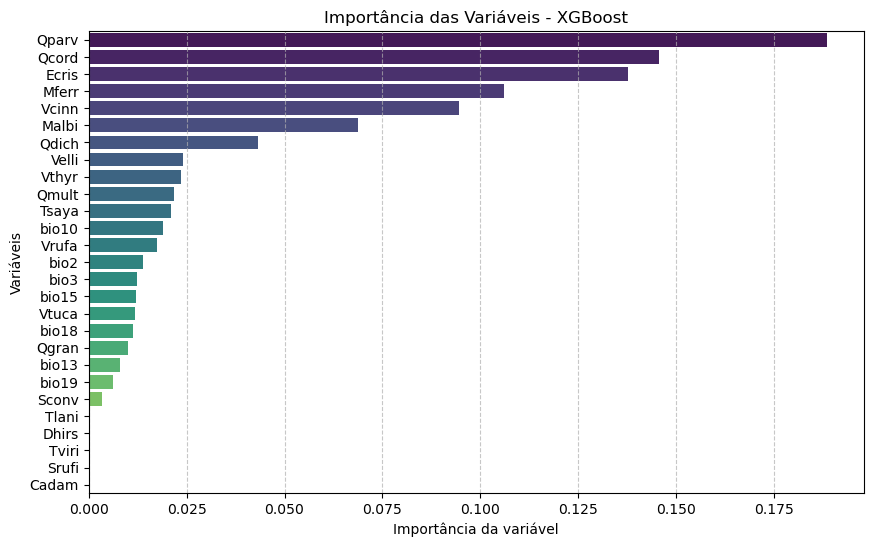

C:\Users\Eduardo Oliveira.PIBILab-01\AppData\Local\Temp\ipykernel_20736\870935806.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=feature_importance_df["Variável"], x=feature_importance_df["Importância"], palette="viridis")


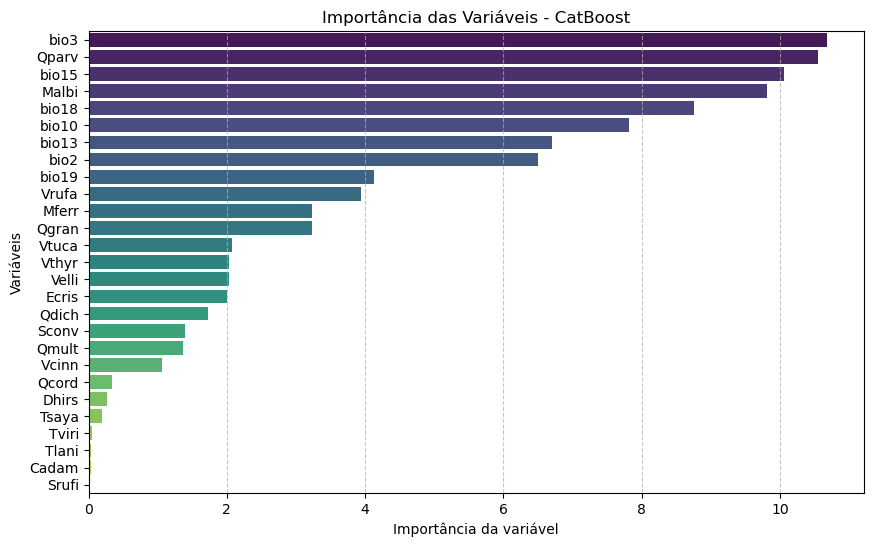

In [66]:
#Fazendo os gráficos

import matplotlib.pyplot as plt
import seaborn as sns

def plot_feature_importance(model, model_name, feature_names):
    """Gera um gráfico de barras com a importância das variáveis"""
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        feature_importance_df = pd.DataFrame({"Variável": feature_names, "Importância": importances})
        feature_importance_df = feature_importance_df.sort_values(by="Importância", ascending=False)

        # Criar o gráfico
        plt.figure(figsize=(10, 6))
        sns.barplot(y=feature_importance_df["Variável"], x=feature_importance_df["Importância"], palette="viridis")
        plt.xlabel("Importância da variável")
        plt.ylabel("Variáveis")
        plt.title(f"Importância das Variáveis - {model_name}")
        plt.grid(axis="x", linestyle="--", alpha=0.7)

        # Salvar a figura
        plt.savefig(f"{model_name}_feature_importance.png", dpi=300, bbox_inches="tight")

        # Mostrar o gráfico
        plt.show()
    else:
        print(f"{model_name} não possui o atributo feature_importances_.")

# Gerar gráfico para XGBoost
plot_feature_importance(xgb_model, "XGBoost", X_train.columns)

# Gerar gráfico para CatBoost
plot_feature_importance(catboost_model, "CatBoost", X_train.columns)
